## Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier


In [2]:
# for the model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

# for feature engineering
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine import imputation as mdi
from feature_engine import encoding as ce
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

## Read in dataset

In [3]:
df = pd.read_csv("urban_pluvial_flood_risk_dataset - modified.csv")
df.head()

,segment_id,city_name,City Name,Country,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,...,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels,GDP Per Capita (AVG LAST 20 YEARS),Rule of Law (AVG LAST 5 YEARS),Control of Corruption (AVG LAST 5 YEARS),Population density
0,SEG-00001,"Colombo, Sri Lanka",Colombo,Sri Lanka,Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,...,160.5,CurbInlet,ERA5,39.4,50,monitor,3182.182138,-0.019547,-0.351644,358.567734
1,SEG-00002,"Chennai, India",Chennai,India,Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,...,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02,1591.666004,0.013641,-0.320317,479.425537
2,SEG-00003,"Ahmedabad, India",Ahmedabad,India,Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,...,152.5,OpenChannel,IMD,16.3,5,monitor,1591.666004,0.013641,-0.320317,479.425537
3,SEG-00004,"Hong Kong, China",Hong Kong,China,Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,...,37.0,Manhole,ERA5,77.0,10,monitor,7420.889647,-0.087245,-0.068543,150.420048
4,SEG-00005,"Durban, South Africa",Durban,South Africa,Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,...,292.4,OpenChannel,ERA5,20.8,5,monitor,6582.141022,-0.048068,-0.147938,51.421090


In [4]:
df = df.drop(['segment_id','city_name'],axis=1) # drop irrelevant columns

In [5]:
df = df.rename({'City Name':'city','Country':'country','Population density':'population_density'},axis=1)

In [6]:
col_dict = {}
for col in df.columns:
    if col.lower() != col:
        col_dict[col] = col.lower().replace(' ','_').split('_(')[0]

col_dict

{'GDP Per Capita (AVG LAST 20 YEARS)': 'gdp_per_capita',
 'Rule of Law (AVG LAST 5 YEARS)': 'rule_of_law',
 'Control of Corruption (AVG LAST 5 YEARS)': 'control_of_corruption'}

In [7]:
df = df.rename(col_dict,axis=1) # rename columns for consistency

## Checking Country Column does not contain duplicates & is accurate

In [8]:
df['country'].value_counts().head()

country
India           375
USA             363
China           158
South Africa    104
Netherlands     104
Name: count, dtype: int64

### Cleaning target variable

In [9]:
df['risk_labels'].value_counts().head(30)

risk_labels
monitor                                                            1991
low_lying                                                           386
extreme_rain_history                                                137
sparse_drainage                                                      88
ponding_hotspot|low_lying                                            78
ponding_hotspot|extreme_rain_history|low_lying                       39
low_lying|sparse_drainage                                            21
extreme_rain_history|low_lying                                       11
ponding_hotspot|extreme_rain_history                                  8
extreme_rain_history|sparse_drainage                                  6
ponding_hotspot|low_lying|sparse_drainage                             6
ponding_hotspot|low_lying|event_2024-07-26                            2
ponding_hotspot                                                       2
ponding_hotspot|low_lying|event_2024-08-19          

In [10]:
# Most common seem to be 1. monitor 2. low_lying 3. extreme_rain_history 4. ponding_hotspot

In [11]:
df['risk_labels'].value_counts().tail(10)

risk_labels
ponding_hotspot|low_lying|event_2024-07-17         1
sparse_drainage|event_2024-11-13                   1
ponding_hotspot|low_lying|event_2024-12-24         1
sparse_drainage|event_2023-10-01                   1
sparse_drainage|event_2022-07-29                   1
ponding_hotspot|low_lying|event_2023-06-21         1
ponding_hotspot|low_lying|event_2022-06-14         1
extreme_rain_history|low_lying|event_2025-04-14    1
low_lying|event_2022-06-11                         1
extreme_rain_history|low_lying|event_2023-11-07    1
Name: count, dtype: int64

In [12]:
# Many one off events

## Solution: Split the column at the pipe and keep only the first event

In [13]:
df['target'] = df['risk_labels'].str.split('|').str[0]

In [14]:
df['target'].value_counts()

target
monitor                 1994
low_lying                449
ponding_hotspot          222
extreme_rain_history     173
sparse_drainage          125
Name: count, dtype: int64

In [15]:
df = df.drop('risk_labels',axis=1)

## Finally we must encode the target variable

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
# Desired mapping
custom_map = {
    'monitor': 0,
    'low_lying': 1,
    'ponding_hotspot': 2,
    'extreme_rain_history': 3,
    'sparse_drainage': 4
}

# Apply it
df['target_encoded'] = df['target'].map(custom_map)

# Check if any got turned to NaN (i.e. any label not in the map)
missing = df.loc[df['target_encoded'].isna(), 'target'].unique()
if len(missing) > 0:
    print("Unmapped classes:", missing)

In [18]:
# Show a few sample rows to check
print(df[['target', 'target_encoded']].head(10))

                 target  target_encoded
0               monitor               0
1       ponding_hotspot               2
2               monitor               0
3               monitor               0
4               monitor               0
5  extreme_rain_history               3
6               monitor               0
7               monitor               0
8             low_lying               1
9               monitor               0


In [19]:
# instead of having multiple categories we will condense into flood/no-flood

df['target_encoded'].value_counts()

target_encoded
0    1994
1     449
2     222
3     173
4     125
Name: count, dtype: int64

In [20]:
df['flood'] = np.where(df['target_encoded'] == 0, 0, 1)
df['flood'].value_counts()

flood
0    1994
1     969
Name: count, dtype: int64

## Inspecting categorical columns

In [21]:
df['dem_source'].value_counts()

dem_source
Copernicus_GLO-30_v2023    869
SRTM_1arc                  783
SRTM_3arc                  550
Copernicus_EEA-10_v5       500
Copernicus_GLO-90_v2022    261
Name: count, dtype: int64

In [22]:
# this column describes the type of DEM model used

# seems unrelated to the predicting floods so we will drop it

In [23]:
df = df.drop('dem_source',axis=1)

In [24]:
df['catchment_id'].value_counts()

catchment_id
CAT-012    28
CAT-163    27
CAT-005    26
CAT-038    26
CAT-091    25
           ..
CAT-176     9
CAT-102     9
CAT-013     9
CAT-154     8
CAT-133     7
Name: count, Length: 180, dtype: int64

In [25]:
# a unique identifier for each catchement area for data collection purposes

# again not useful for predicting floods so we will drop it

In [26]:
#df = df.drop('catchment_id',axis=1)

In [27]:
df['rainfall_source'].value_counts()

rainfall_source
ERA5          1334
LocalGauge     502
Blended        445
IMD            367
Name: count, dtype: int64

In [28]:
# rainfall source is how the rainfall data was collected and so not important in predicting floods

# so it will be dropped

In [29]:
df = df.drop('rainfall_source',axis=1)

## Summary statistics

In [30]:
df.drop(columns=['latitude','longitude']).describe().round(2)

,elevation_m,drainage_density_km_per_km2,storm_drain_proximity_m,historical_rainfall_intensity_mm_hr,return_period_years,gdp_per_capita,rule_of_law,control_of_corruption,population_density,target_encoded,flood
count,2802.00,2679.00,2724.00,2963.00,2963.00,2921.00,2921.00,2921.00,2921.00,2963.00,2963.00
mean,37.69,6.29,123.20,43.81,19.73,24596.39,0.48,0.37,350.15,0.65,0.33
std,38.71,2.19,107.76,25.22,25.18,23086.87,0.86,0.97,1053.55,1.11,0.47
min,-3.00,1.27,0.20,5.40,2.00,1226.23,-0.94,-1.13,3.38,0.00,0.00
25%,8.73,4.67,47.98,25.80,5.00,2649.70,-0.13,-0.35,36.51,0.00,0.00
50%,25.13,6.25,91.70,37.90,10.00,10395.24,0.01,-0.07,141.86,0.00,0.00
75%,59.62,7.83,162.62,55.55,25.00,46783.17,1.37,1.09,343.28,1.00,1.00
max,266.70,12.07,751.70,150.00,100.00,73988.31,1.87,2.29,7851.01,4.00,1.00


In [31]:
# population denisty has an extreme outlier

<Axes: >

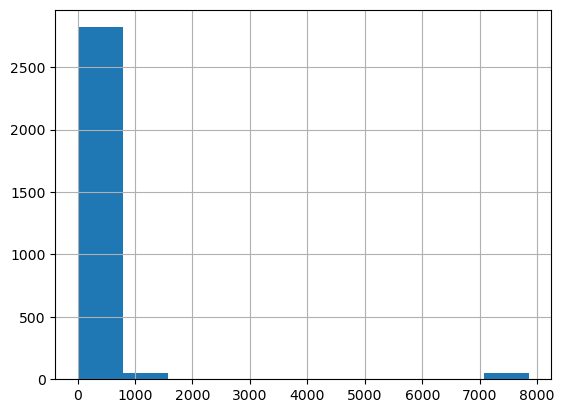

In [32]:
df['population_density'].hist()

In [33]:
df[df['population_density'] == max(df['population_density'])].head(3)

,city,country,admin_ward,latitude,longitude,catchment_id,elevation_m,land_use,soil_group,drainage_density_km_per_km2,...,storm_drain_type,historical_rainfall_intensity_mm_hr,return_period_years,gdp_per_capita,rule_of_law,control_of_corruption,population_density,target,target_encoded,flood
20,Singapore,Singapore,District 14,1.387557,103.790327,CAT-009,NaN,Roads,D,5.23,...,Manhole,63.6,25,56927.93824,1.804863,2.102534,7851.005571,monitor,0,0
56,Singapore,Singapore,District 14,1.390561,103.837383,CAT-166,NaN,Roads,NaN,8.34,...,CurbInlet,150.0,50,56927.93824,1.804863,2.102534,7851.005571,ponding_hotspot,2,1
87,Singapore,Singapore,Ward F,1.303470,103.820979,CAT-147,2.95,Commercial,A,9.32,...,Manhole,52.8,25,56927.93824,1.804863,2.102534,7851.005571,low_lying,1,1


In [34]:
# outlier is singapore so is real and can be kept

## Histograms for all numeric variables

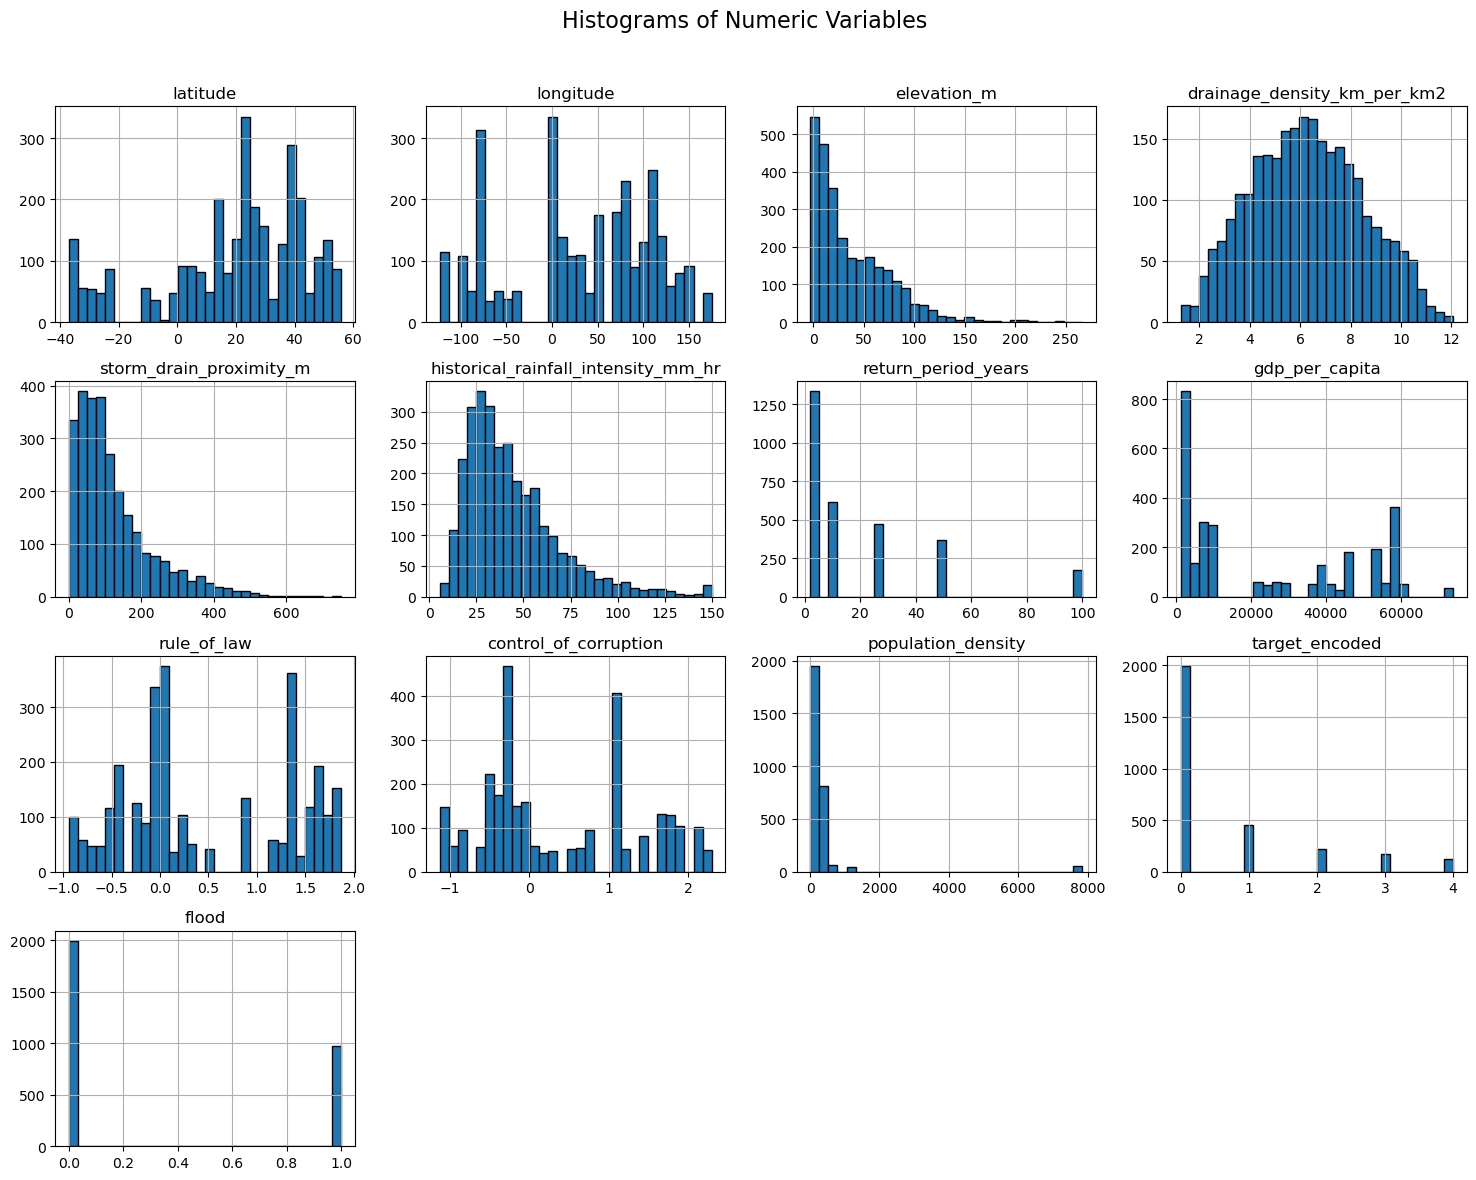

In [35]:
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols].hist(figsize=(15, 12), bins=30, edgecolor='black')

plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [36]:
# elevation has a heavy positive skew, take the log to make normal

<Axes: >

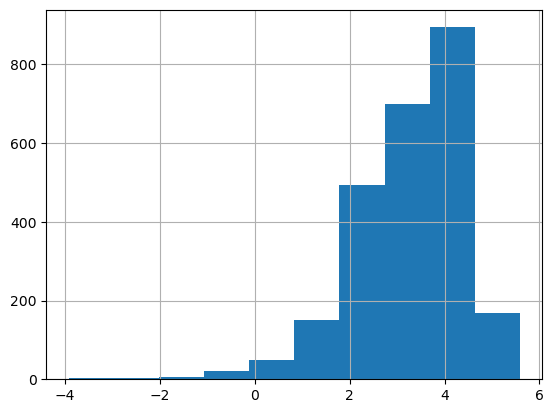

In [37]:
np.log(df[df['elevation_m'] >=0 ]['elevation_m']).hist()

## Correlation Matrix

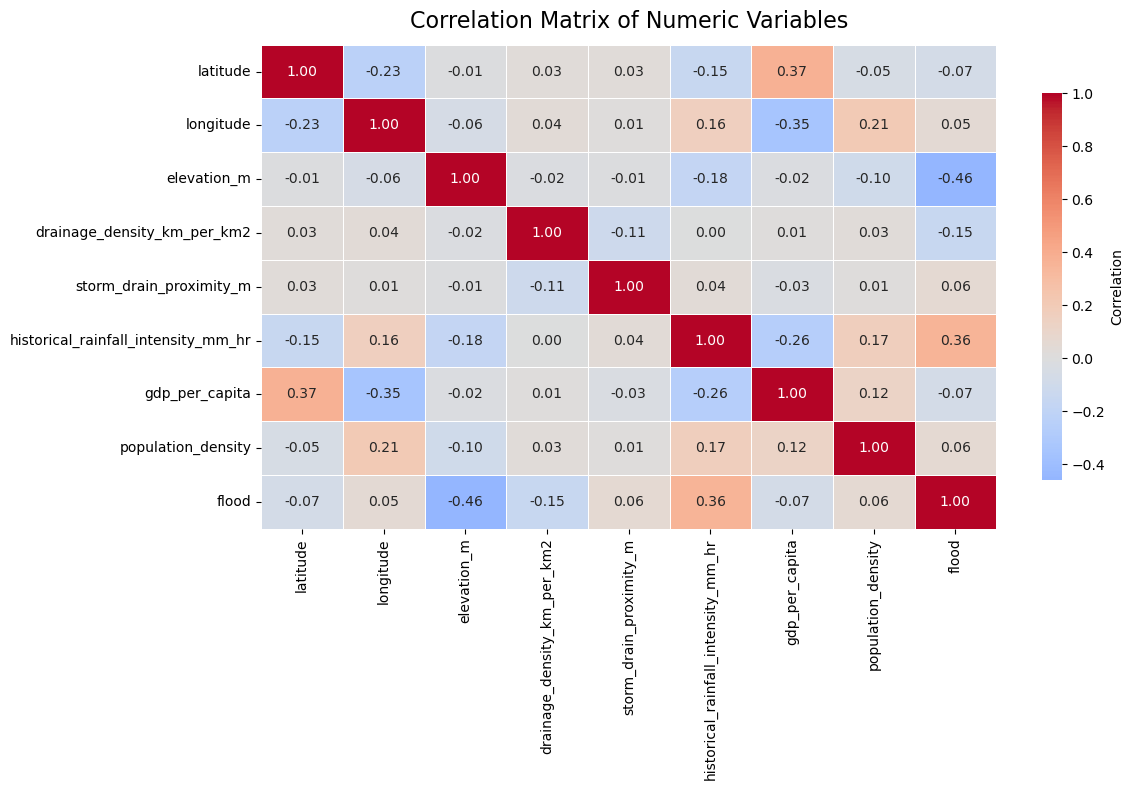

In [38]:
# Compute correlation matrix
corr = df.drop(['target_encoded','rule_of_law','control_of_corruption','return_period_years'],axis=1).corr(numeric_only=True).round(2)

# Set up the figure
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,            # show correlation values
    fmt=".2f",             # 2 decimal places
    cmap='coolwarm',       # color palette
    center=0,              # 0 correlation centered
    linewidths=0.5,        # gridlines
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
)

plt.title("Correlation Matrix of Numeric Variables", fontsize=16, pad=12)
plt.tight_layout()
plt.show()

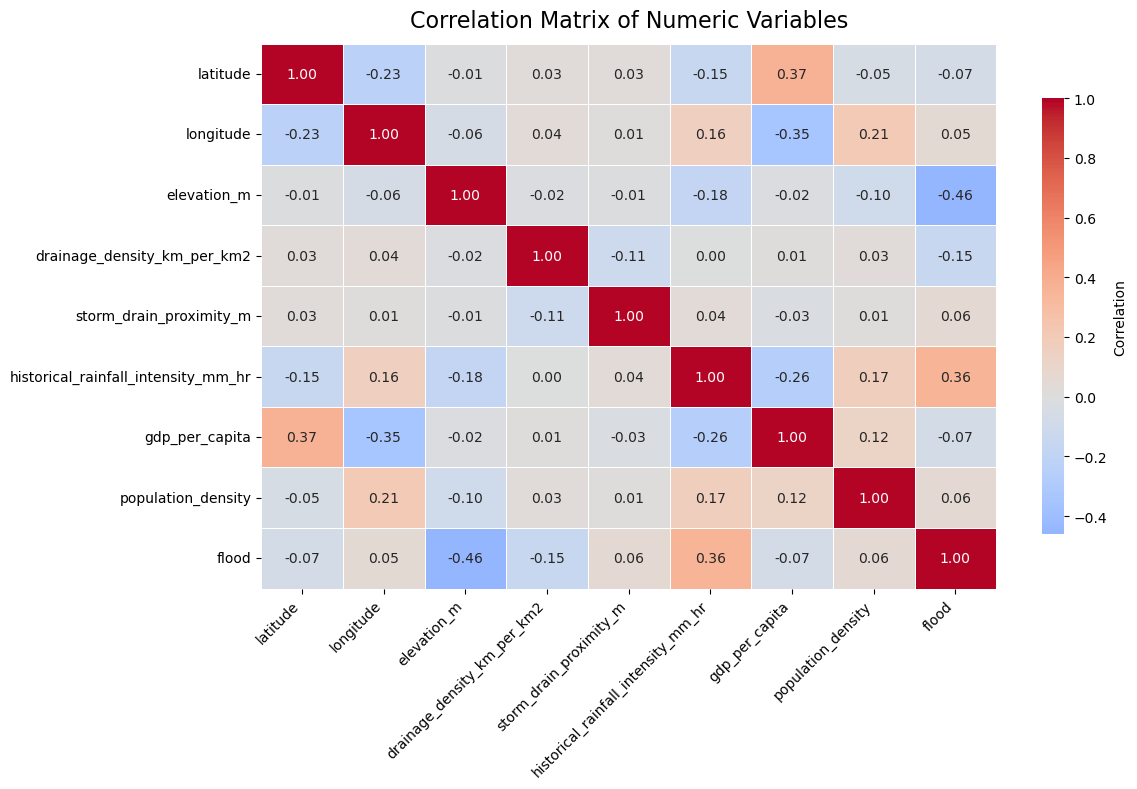

In [39]:
# Compute correlation matrix
corr = df.drop(
    ['target_encoded', 'rule_of_law', 'control_of_corruption', 'return_period_years'],
    axis=1
).corr(numeric_only=True).round(2)

# Set up the figure
plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

plt.title("Correlation Matrix of Numeric Variables", fontsize=16, pad=12)
plt.tight_layout()
plt.show()


## Target variable analysis

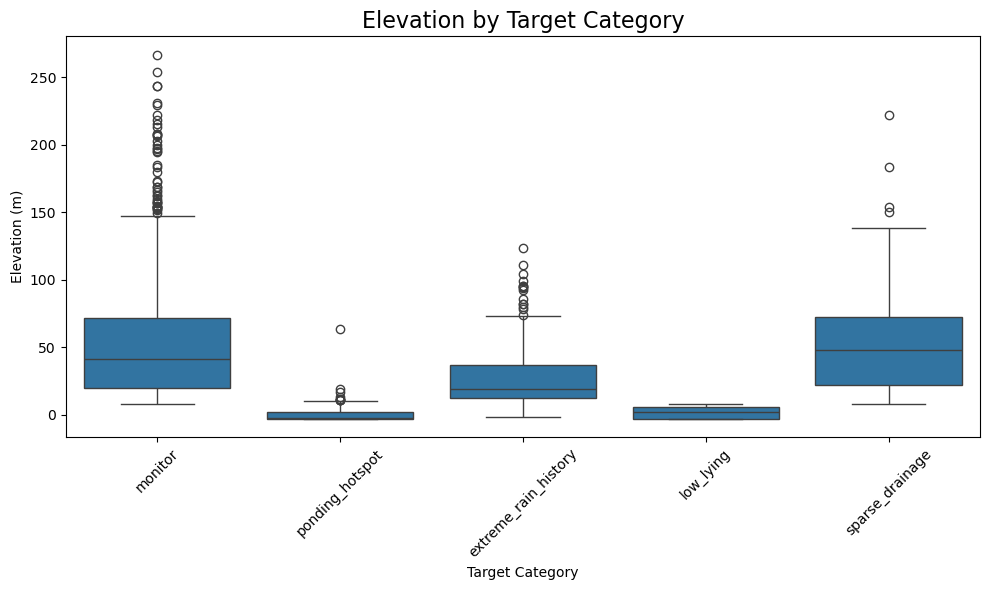

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(x='target', y='elevation_m', data=df)
plt.title('Elevation by Target Category', fontsize=16)
plt.xlabel('Target Category')
plt.ylabel('Elevation (m)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

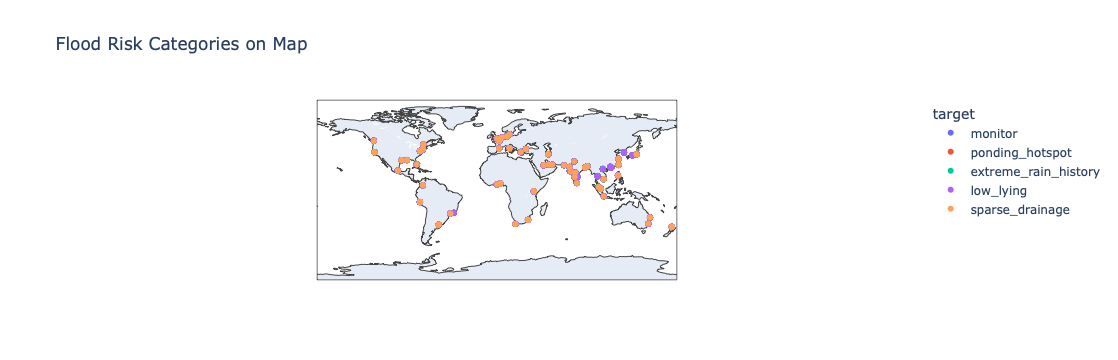

In [41]:
px.scatter_geo(df, lat='latitude', lon='longitude', color='target', hover_name='city', title='Flood Risk Categories on Map')

<Axes: ylabel='count'>

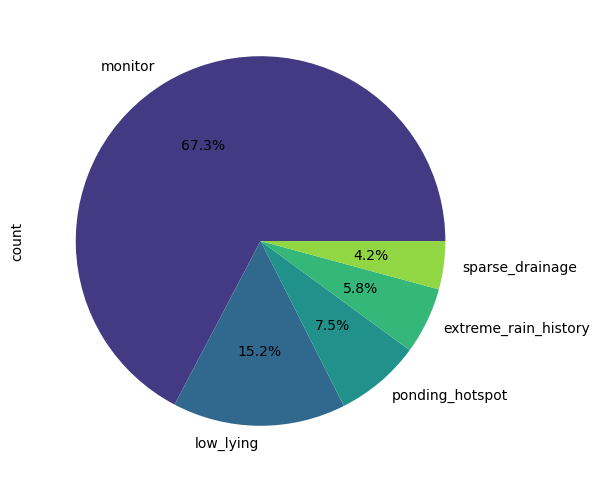

In [42]:
df['target'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6), colors=sns.color_palette('viridis', 5))

<Axes: ylabel='count'>

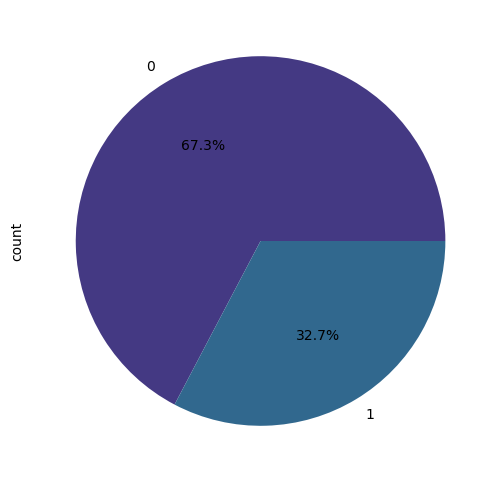

In [43]:
df['flood'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6), colors=sns.color_palette('viridis', 5))

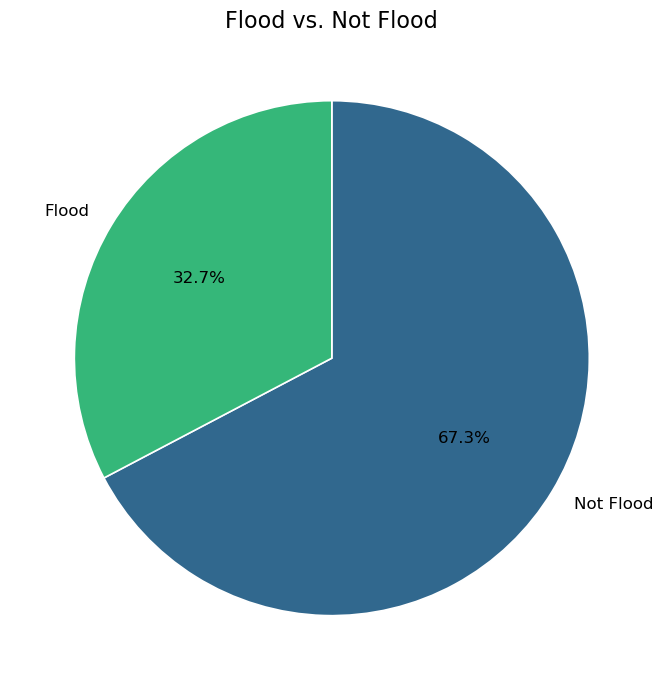

In [44]:
plt.figure(figsize=(7,7))

labels = ['Not Flood', 'Flood']

df['flood'].value_counts().plot.pie(
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    colors=sns.color_palette("viridis", len(labels)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'fontsize': 12}
)

plt.title("Flood vs. Not Flood", fontsize=16)
plt.ylabel("")
plt.tight_layout()
plt.show()

## Feature Engineering

## Creating a region column

In [45]:
# To apply ordinal encoding

regions_map = {
    # North America
    'Canada': 'North America', 'United States': 'North America', 'USA': 'North America',
    'Mexico': 'Latin America & Caribbean',
    # Latin America & Caribbean (examples)
    'Brazil': 'Latin America & Caribbean', 'Argentina': 'Latin America & Caribbean',
    'Chile': 'Latin America & Caribbean', 'Colombia': 'Latin America & Caribbean',
    'Peru': 'Latin America & Caribbean', 'Dominican Republic': 'Latin America & Caribbean',
    # Europe
    'United Kingdom': 'Europe', 'UK': 'Europe', 'Denmark': 'Europe', 'France': 'Europe',
    'Germany': 'Europe', 'Greece': 'Europe', 'Spain': 'Europe', 'Italy': 'Europe',
    'Netherlands': 'Europe', 'Poland': 'Europe', 'Sweden': 'Europe',
    # Sub-Saharan Africa
    'South Africa': 'Sub-Saharan Africa', 'Nigeria': 'Sub-Saharan Africa', 'Kenya': 'Sub-Saharan Africa',
    'Ghana': 'Sub-Saharan Africa', 'Ethiopia': 'Sub-Saharan Africa',
    # MENA
    'Morocco': 'MENA', 'Egypt': 'MENA', 'Saudi Arabia': 'MENA', 'United Arab Emirates': 'MENA',
    'UAE': 'MENA', 'Qatar': 'MENA', 'Iran': 'MENA', 'Turkey': 'MENA',
    # East Asia
    'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia', 'Korea, Republic of': 'East Asia',
    'Mongolia': 'East Asia', 'Taiwan': 'East Asia',
    # South Asia
    'India': 'South Asia', 'Pakistan': 'South Asia', 'Bangladesh': 'South Asia',
    'Sri Lanka': 'South Asia', 'Nepal': 'South Asia',
    # Southeast Asia
    'Singapore': 'Southeast Asia', 'Malaysia': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Philippines': 'Southeast Asia', 'Vietnam': 'Southeast Asia', 'Thailand': 'Southeast Asia',
    'Cambodia': 'Southeast Asia', 'Laos': 'Southeast Asia', 'Myanmar': 'Southeast Asia',
    # Central Asia
    'Kazakhstan': 'Central Asia', 'Uzbekistan': 'Central Asia', 'Kyrgyzstan': 'Central Asia',
    'Tajikistan': 'Central Asia', 'Turkmenistan': 'Central Asia',
    # Oceania
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}

df['region'] = df['country'].map(regions_map).fillna('Other')
df['region'].value_counts()

region
South Asia                   499
North America                465
Europe                       435
East Asia                    338
Southeast Asia               320
Latin America & Caribbean    291
Sub-Saharan Africa           247
MENA                         229
Oceania                      139
Name: count, dtype: int64

### Taking the log of positively skewed columns

In [46]:
df['storm_drain_proximity_m'].describe().round(2)

count    2724.00
mean      123.20
std       107.76
min         0.20
25%        47.98
50%        91.70
75%       162.62
max       751.70
Name: storm_drain_proximity_m, dtype: float64

In [47]:
df['log_storm_drain_proximity_m'] = np.log(df['storm_drain_proximity_m'])

In [48]:
df['historical_rainfall_intensity_mm_hr'].describe().round(2)

count    2963.00
mean       43.81
std        25.22
min         5.40
25%        25.80
50%        37.90
75%        55.55
max       150.00
Name: historical_rainfall_intensity_mm_hr, dtype: float64

In [49]:
df['log_historical_rainfall_intensity_mm_hr'] = np.log(df['historical_rainfall_intensity_mm_hr'])

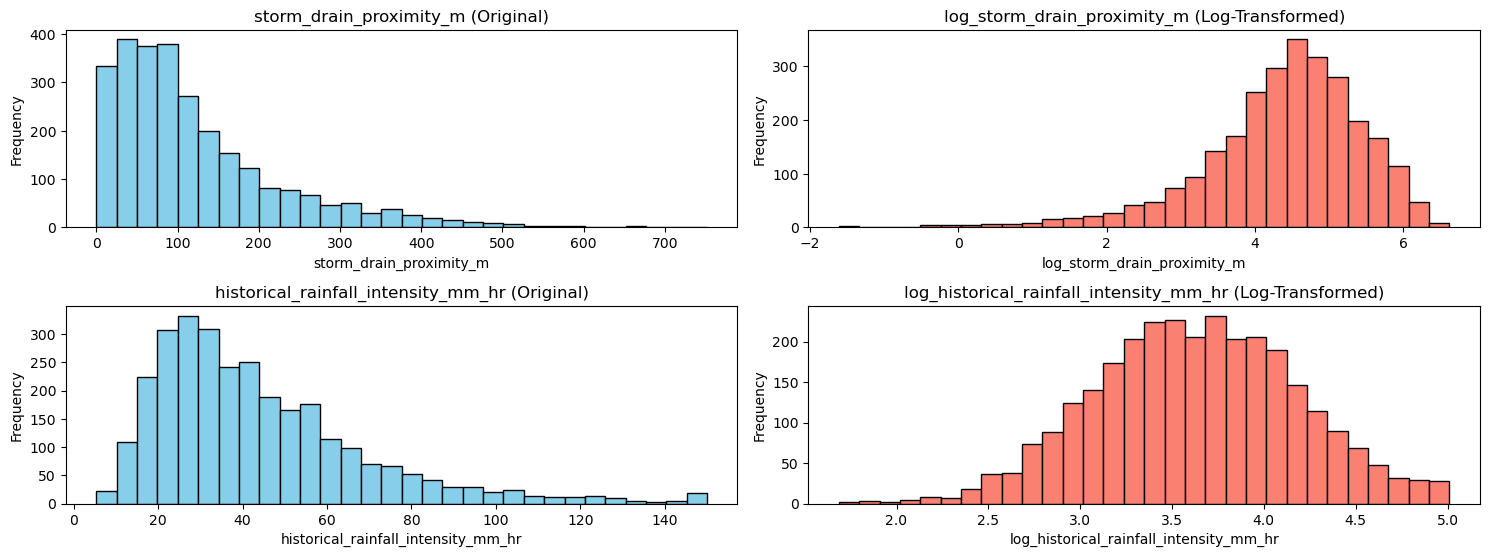

In [50]:
cols = [
    ("storm_drain_proximity_m", "log_storm_drain_proximity_m"),
    ("historical_rainfall_intensity_mm_hr", "log_historical_rainfall_intensity_mm_hr")
]

plt.figure(figsize=(15, 8))

for i, (orig, log) in enumerate(cols, 1):
    # Original
    plt.subplot(3, 2, 2*i - 1)
    plt.hist(df[orig].dropna(), bins=30, color="skyblue", edgecolor="black")
    plt.title(f"{orig} (Original)")
    plt.xlabel(orig)
    plt.ylabel("Frequency")

    # Log-transformed
    plt.subplot(3, 2, 2*i)
    plt.hist(df[log].dropna(), bins=30, color="salmon", edgecolor="black")
    plt.title(f"{log} (Log-Transformed)")
    plt.xlabel(log)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [51]:
df = df.drop(['storm_drain_proximity_m','historical_rainfall_intensity_mm_hr'],axis=1)

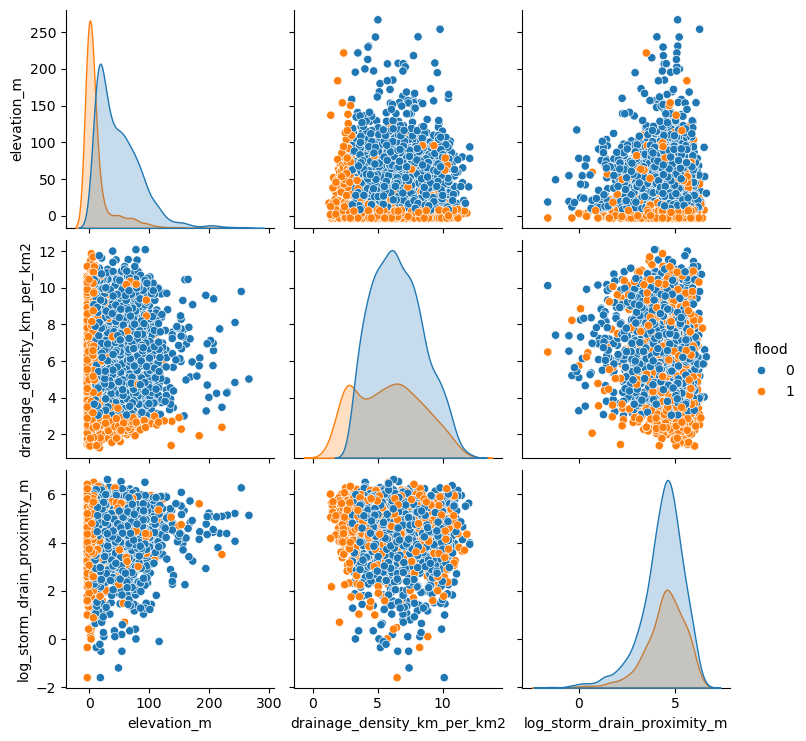

In [52]:
sns.pairplot(df, vars=['elevation_m', 'drainage_density_km_per_km2', 'log_storm_drain_proximity_m'], hue='flood');

## Split the data

In [53]:
X = df.drop(columns=['target', 'target_encoded','country', 'admin_ward','flood'])
y = df['flood']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

X_train.shape, X_test.shape

((2666, 17), (297, 17))

## Impute missing values

In [54]:
df.isna().sum()[df.isna().sum() > 0]

elevation_m                    161
soil_group                     362
drainage_density_km_per_km2    284
storm_drain_type               178
gdp_per_capita                  42
rule_of_law                     42
control_of_corruption           42
population_density              42
log_storm_drain_proximity_m    239
dtype: int64

## Elevation missing values

In [55]:
df[df['elevation_m'].isna()].head(3)

,city,country,admin_ward,latitude,longitude,catchment_id,elevation_m,land_use,soil_group,drainage_density_km_per_km2,...,gdp_per_capita,rule_of_law,control_of_corruption,population_density,target,target_encoded,flood,region,log_storm_drain_proximity_m,log_historical_rainfall_intensity_mm_hr
0,Colombo,Sri Lanka,Borough East,6.920633,79.912600,CAT-136,NaN,Institutional,NaN,4.27,...,3182.182138,-0.019547,-0.351644,358.567734,monitor,0,0,South Asia,5.078294,3.673766
20,Singapore,Singapore,District 14,1.387557,103.790327,CAT-009,NaN,Roads,D,5.23,...,56927.938240,1.804863,2.102534,7851.005571,monitor,0,0,Southeast Asia,3.666122,4.152613
22,Chennai,India,District 3,13.171312,80.196503,CAT-080,NaN,Green,C,4.39,...,1591.666004,0.013641,-0.320317,479.425537,monitor,0,0,South Asia,5.073297,3.981549


In [56]:
df[df['city'] == 'Colombo'].head()

,city,country,admin_ward,latitude,longitude,catchment_id,elevation_m,land_use,soil_group,drainage_density_km_per_km2,...,gdp_per_capita,rule_of_law,control_of_corruption,population_density,target,target_encoded,flood,region,log_storm_drain_proximity_m,log_historical_rainfall_intensity_mm_hr
0,Colombo,Sri Lanka,Borough East,6.920633,79.912600,CAT-136,NaN,Institutional,NaN,4.27,...,3182.182138,-0.019547,-0.351644,358.567734,monitor,0,0,South Asia,5.078294,3.673766
39,Colombo,Sri Lanka,Sector 9,6.946996,79.866172,CAT-096,9.86,Green,C,NaN,...,3182.182138,-0.019547,-0.351644,358.567734,monitor,0,0,South Asia,2.322388,4.279440
81,Colombo,Sri Lanka,Ward E,6.843577,79.842526,CAT-116,17.18,Green,C,2.93,...,3182.182138,-0.019547,-0.351644,358.567734,sparse_drainage,4,1,South Asia,5.042134,3.939638
348,Colombo,Sri Lanka,Zone III,6.938703,79.797244,CAT-136,22.39,Commercial,B,4.59,...,3182.182138,-0.019547,-0.351644,358.567734,extreme_rain_history,3,1,South Asia,4.997212,4.609162
425,Colombo,Sri Lanka,Ward B,7.011328,79.850977,CAT-041,17.26,Green,C,1.27,...,3182.182138,-0.019547,-0.351644,358.567734,extreme_rain_history,3,1,South Asia,NaN,4.666265


In [57]:
cols = ['latitude', 'longitude', 'elevation_m']

imputer = KNNImputer(n_neighbors=3, weights='distance')

# Fit only on training data
tmp_train = X_train[cols].copy()
tmp_test  = X_test[cols].copy()

# Fit on train
imputer.fit(tmp_train)

# Transform both
imputed_train = imputer.transform(tmp_train)
imputed_test  = imputer.transform(tmp_test)

# Assign back
X_train['elevation_m'] = imputed_train[:, 2]
X_test['elevation_m']  = imputed_test[:, 2]

In [58]:
X_train[cols].isna().sum(),X_test[cols].isna().sum()

(latitude       0
 longitude      0
 elevation_m    0
 dtype: int64,
 latitude       0
 longitude      0
 elevation_m    0
 dtype: int64)

## Soil group missing values

In [59]:
# Step 1: compute city-wise mode on TRAIN ONLY
city_mode = (
    X_train.dropna(subset=['soil_group'])
           .groupby('city')['soil_group']
           .agg(lambda s: s.mode().iloc[0])
)

# Optional global fallback mode
global_mode = X_train['soil_group'].mode().iloc[0]

def fill_soil(row):
    if pd.isna(row['soil_group']):
        return city_mode.get(row['city'], global_mode)
    return row['soil_group']

# Step 2: apply to train and test (using mapping learned from train)
X_train['soil_group'] = X_train.apply(fill_soil, axis=1)
X_test['soil_group']  = X_test.apply(fill_soil, axis=1)


## Storm drain missing values

In [60]:
# storm drain mode per city (train only)
city_mode_storm = (
    X_train.dropna(subset=['storm_drain_type'])
           .groupby('city')['storm_drain_type']
           .agg(lambda s: s.mode().iloc[0])
)


# optional global modes (for cities that appear only in X_test)
global_storm_mode = X_train['storm_drain_type'].mode().iloc[0]


def fill_storm(row):
    if pd.isna(row['storm_drain_type']):
        return city_mode_storm.get(row['city'], global_storm_mode)
    return row['storm_drain_type']



X_train['storm_drain_type'] = X_train.apply(fill_storm, axis=1)
X_test['storm_drain_type']  = X_test.apply(fill_storm, axis=1)


In [61]:
print(X_train[['storm_drain_type']].isna().sum())
print(X_test[['storm_drain_type']].isna().sum())

storm_drain_type    0
dtype: int64
storm_drain_type    0
dtype: int64


In [62]:
X_train.columns

Index(['city', 'latitude', 'longitude', 'catchment_id', 'elevation_m',
       'land_use', 'soil_group', 'drainage_density_km_per_km2',
       'storm_drain_type', 'return_period_years', 'gdp_per_capita',
       'rule_of_law', 'control_of_corruption', 'population_density', 'region',
       'log_storm_drain_proximity_m',
       'log_historical_rainfall_intensity_mm_hr'],
      dtype='object')

In [63]:
# Columns to impute
num_cols = ['drainage_density_km_per_km2', 'log_storm_drain_proximity_m']

# 1) Compute city-level medians on TRAIN ONLY
city_medians = (
    X_train.groupby('city')[num_cols]
           .median(numeric_only=True)
)

# Optional: global medians as fallback for unseen cities in X_test
global_medians = X_train[num_cols].median(numeric_only=True)

# 2) Helper function: fill with city median (or global if city unseen)
def fill_with_city_median(row, col):
    if pd.isna(row[col]):
        city = row['city']
        if city in city_medians.index:
            return city_medians.loc[city, col]
        else:
            return global_medians[col]
    return row[col]

# 3) Apply to both X_train and X_test using mapping learned from X_train
for col in num_cols:
    X_train[col] = X_train.apply(lambda row, c=col: fill_with_city_median(row, c), axis=1)
    X_test[col]  = X_test.apply(lambda row, c=col: fill_with_city_median(row, c), axis=1)

# 4) Optional — verify
print(X_train[num_cols].isna().sum())
print(X_test[num_cols].isna().sum())

drainage_density_km_per_km2    0
log_storm_drain_proximity_m    0
dtype: int64
drainage_density_km_per_km2    0
log_storm_drain_proximity_m    0
dtype: int64


In [64]:
X_train = X_train.dropna()
X_test = X_test.dropna()

y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]

## One Hot Encoding

In [65]:
df['storm_drain_type'].value_counts()

storm_drain_type
CurbInlet      843
Manhole        749
GratedInlet    644
OpenChannel    549
Name: count, dtype: int64

In [66]:
df['soil_group'].value_counts()

soil_group
B    747
C    713
D    594
A    547
Name: count, dtype: int64

In [67]:
df['land_use'].value_counts()

land_use
Residential      827
Roads            599
Commercial       493
Green            359
Industrial       357
Mixed            110
Institutional    106
Water             83
Informal          29
Name: count, dtype: int64

In [68]:
X_train = pd.get_dummies(X_train, columns=['soil_group', 'land_use','storm_drain_type','region'], dtype=int)
X_test  = pd.get_dummies(X_test,  columns=['soil_group', 'land_use','storm_drain_type','region'], dtype=int)

In [69]:
X_train.head(1)

,city,latitude,longitude,catchment_id,elevation_m,drainage_density_km_per_km2,return_period_years,gdp_per_capita,rule_of_law,control_of_corruption,...,storm_drain_type_OpenChannel,region_East Asia,region_Europe,region_Latin America & Caribbean,region_MENA,region_North America,region_Oceania,region_South Asia,region_Southeast Asia,region_Sub-Saharan Africa
2811,Durban,-29.854879,31.077289,CAT-109,89.14,6.56,2,6582.141022,-0.048068,-0.147938,...,0,0,0,0,0,0,0,0,0,1


## Transform some columns

In [70]:
pt = PowerTransformer(method='yeo-johnson')
X_train['elevation_m'] = pt.fit_transform(X_train[['elevation_m']])
X_test['elevation_m'] = pt.transform(X_test[['elevation_m']])

## Derived variables

In [71]:
# Capture whether the segment is lower/higher than its neighbors in the same catchment

# containers
X_train['elev_local_delta_knn'] = np.nan
X_test['elev_local_delta_knn']  = np.nan

k = 8

# TRAIN: k-NN within each catchment (self neighbors excluded)
# Loop over each catchment present in the training data.
for cid in X_train['catchment_id'].unique():
    g = X_train.loc[X_train['catchment_id'] == cid]
    n = len(g)
    # k-NN cannot be performed where there is only one datapoint
    if n <= 1:
        continue

    # exclude self
    k_eff = min(k, n - 1)
    # converts lat/lon degrees to radians
    coords_rad = np.deg2rad(g[['latitude','longitude']].to_numpy())
    # Initializes a k-NN model using haversine distance over spherical coordinates
    nn = NearestNeighbors(
        # +1 to include self, will drop it
        n_neighbors=k_eff + 1,
        algorithm='ball_tree',
        metric='haversine'
    ).fit(coords_rad)

    # drop self (col 0)
    idxs = nn.kneighbors(coords_rad, return_distance=False)[:,1:]

    # Grabs elevations as a NumPy array and allocates an array to store neighbor-mean elevations.
    elev = g['elevation_m'].to_numpy()
    # How much higher/lower it is than the average of its k nearest neighbors
    X_train.loc[g.index, 'elev_local_delta_knn'] = elev - np.array([elev[i].mean() for i in idxs])

# TEST: use TRAIN as the neighbor reference within the same catchment (no leakage)
for cid in X_test['catchment_id'].unique():
    g_te = X_test.loc[X_test['catchment_id'] == cid]
    g_tr = X_train.loc[X_train['catchment_id'] == cid]

    # Case A: we have train points for this catchment (preferred, no leakage)
    if len(g_tr) >= 1:
        k_eff = min(k, len(g_tr))

        ref_coords = np.deg2rad(g_tr[['latitude','longitude']].to_numpy())
        qry_coords = np.deg2rad(g_te[['latitude','longitude']].to_numpy())

        nn = NearestNeighbors(
            n_neighbors=k_eff,
            algorithm='ball_tree',
            metric='haversine'
        ).fit(ref_coords)

        idxs = nn.kneighbors(qry_coords, return_distance=False)  # shape: (len(g_te), k_eff)
        ref_elev = g_tr['elevation_m'].to_numpy()                # shape: (len(g_tr),)

        # mean elevation of the k train neighbors for each TEST row
        neigh_mean = np.array([ref_elev[i].mean() for i in idxs])   # shape: (len(g_te),)

        # local delta for TEST rows: test_elev - mean(train neighbors)
        test_elev = g_te['elevation_m'].to_numpy()                  # shape: (len(g_te),)
        deltas = test_elev - neigh_mean

        # write back to the correct TEST rows
        X_test.loc[g_te.index, 'elev_local_delta_knn'] = deltas

    # Case B: catchment only in test, fallback to within-test neighbors
    else:
        n = len(g_te)
        if n <= 1:
            continue

        k_eff = min(k, n - 1)
        coords = np.deg2rad(g_te[['latitude','longitude']].to_numpy())
        nn = NearestNeighbors(n_neighbors=k_eff+1, algorithm='ball_tree', metric='haversine').fit(coords)
        idxs = nn.kneighbors(coords, return_distance=False)[:, 1:]  # drop self
        elev = g_te['elevation_m'].to_numpy()
        neigh_mean = np.array([elev[i].mean() for i in idxs])
        X_test.loc[g_te.index, 'elev_local_delta_knn'] = elev - neigh_mean

# Inspect a single catchment
cid0 = X_train['catchment_id'].iloc[0]
X_train.loc[X_train['catchment_id']==cid0, ['latitude','longitude','elevation_m','elev_local_delta_knn']].head()


,latitude,longitude,elevation_m,elev_local_delta_knn
2811,-29.854879,31.077289,1.285785,1.520213
874,51.953381,4.489087,-0.826447,-0.893767
1308,51.872270,4.539728,-0.401724,-0.408369
914,40.859385,28.977664,-0.319667,-0.314590
1856,14.548602,120.981146,-0.358027,-0.358430


## Removing unneccesary columns

In [72]:
X_train = X_train.drop(columns=['catchment_id','city'], errors='ignore')
X_test  = X_test.drop(columns=['catchment_id','city'], errors='ignore')

print(X_train.dtypes)
print('\n')
print(X_test.dtypes)

latitude                                   float64
longitude                                  float64
elevation_m                                float64
drainage_density_km_per_km2                float64
return_period_years                          int64
gdp_per_capita                             float64
rule_of_law                                float64
control_of_corruption                      float64
population_density                         float64
log_storm_drain_proximity_m                float64
log_historical_rainfall_intensity_mm_hr    float64
soil_group_A                                 int64
soil_group_B                                 int64
soil_group_C                                 int64
soil_group_D                                 int64
land_use_Commercial                          int64
land_use_Green                               int64
land_use_Industrial                          int64
land_use_Informal                            int64
land_use_Institutional         

In [73]:
X_train.shape, y_train.shape

((2627, 38), (2627,))

In [74]:
scale = StandardScaler()

X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

## Quick Model Test

In [75]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression()

logistic.fit(X_train, y_train)

LogisticRegression()

In [76]:
y_train_proba = logistic.predict_proba(X_train)[:,1]
y_test_proba = logistic.predict_proba(X_test)[:,1]

print('Train set')
print('GBM roc-auc: {:.4f}'.format(roc_auc_score(y_train, y_train_proba, multi_class='ovr', average='macro')))

print('Test set')
print('GBM roc-auc: {:.4f}'.format(roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')))

Train set
GBM roc-auc: 0.9093
Test set
GBM roc-auc: 0.8982


## Build Preprocessing and Transformer Pipeline

In [77]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# -----------------------
# Custom transformers
# -----------------------

class RegionAdder(BaseEstimator, TransformerMixin):
    """Add a 'region' column from 'country' using a mapping dict."""
    def __init__(self, region_map):
        self.region_map = region_map

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'region' not in X.columns:
            X['region'] = X['country'].map(self.region_map).fillna('Other')
        return X


class LogTransformer(BaseEstimator, TransformerMixin):
    """Create log-transformed versions of specified positive columns."""
    def __init__(self, cols, new_cols):
        self.cols = cols
        self.new_cols = new_cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, new_col in zip(self.cols, self.new_cols):
            if new_col not in X.columns:
                # small constant avoids log(0)
                X[new_col] = np.log(X[col] + 1e-6)
        return X


class CityMedianImputer(BaseEstimator, TransformerMixin):
    """Impute numeric columns with city-level medians, falling back to global median."""
    def __init__(self, num_cols, city_col='city'):
        self.num_cols = num_cols
        self.city_col = city_col

    def fit(self, X, y=None):
        df = X[[self.city_col] + self.num_cols].copy()
        self.city_medians_ = (
            df.groupby(self.city_col)[self.num_cols]
              .median(numeric_only=True)
        )
        self.global_medians_ = df[self.num_cols].median(numeric_only=True)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.num_cols:
            city_values = X[self.city_col].map(self.city_medians_[col])
            X[col] = X[col].fillna(city_values)
            X[col] = X[col].fillna(self.global_medians_[col])
        return X


class CityModeImputer(BaseEstimator, TransformerMixin):
    """Impute a categorical column with city-level mode, then global mode."""
    def __init__(self, col, city_col='city'):
        self.col = col
        self.city_col = city_col

    def fit(self, X, y=None):
        df = X[[self.city_col, self.col]].copy()
        self.city_mode_ = (
            df.dropna(subset=[self.col])
              .groupby(self.city_col)[self.col]
              .agg(lambda s: s.mode().iloc[0])
        )
        self.global_mode_ = df[self.col].mode().iloc[0]
        return self

    def transform(self, X):
        X = X.copy()
        mapped = X[self.city_col].map(self.city_mode_)
        X[self.col] = X[self.col].fillna(mapped)
        X[self.col] = X[self.col].fillna(self.global_mode_)
        return X


class ElevationKNNImputer(BaseEstimator, TransformerMixin):
    """KNN imputation for elevation using (lat, lon, elevation)."""
    def __init__(self, lat_col='latitude', lon_col='longitude',
                 elev_col='elevation_m', n_neighbors=5):
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.elev_col = elev_col
        self.n_neighbors = n_neighbors

    def fit(self, X, y=None):
        self.imputer_ = KNNImputer(n_neighbors=self.n_neighbors)
        cols = [self.lat_col, self.lon_col, self.elev_col]
        self.imputer_.fit(X[cols])
        self.cols_ = cols
        return self

    def transform(self, X):
        X = X.copy()
        imputed = self.imputer_.transform(X[self.cols_])
        X[self.elev_col] = imputed[:, 2]  # third column is elevation
        return X


class SingleColumnPowerTransformer(BaseEstimator, TransformerMixin):
    """Apply Yeo-Johnson to a single column."""
    def __init__(self, column):
        self.column = column

    def fit(self, X, y=None):
        self.pt_ = PowerTransformer(method='yeo-johnson')
        self.pt_.fit(X[[self.column]])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = self.pt_.transform(X[[self.column]])
        return X


class ElevationLocalDelta(BaseEstimator, TransformerMixin):
    """
    elev_local_delta_knn = elevation - mean(elevation of k nearest neighbours
    in the same catchment, using haversine distance on (lat, lon).
    For transform-time data, neighbours are taken from the training data.
    """
    def __init__(self, catchment_col='catchment_id', lat_col='latitude',
                 lon_col='longitude', elev_col='elevation_m', k=8):
        self.catchment_col = catchment_col
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.elev_col = elev_col
        self.k = k

    def fit(self, X, y=None):
        # store training geo info
        self.train_geo_ = X[[self.catchment_col,
                             self.lat_col,
                             self.lon_col,
                             self.elev_col]].copy()
        return self

    def transform(self, X):
        X = X.copy()
        X['elev_local_delta_knn'] = np.nan

        train_geo = self.train_geo_
        k = self.k

        for cid, g_te in X.groupby(self.catchment_col):
            g_tr = train_geo[train_geo[self.catchment_col] == cid]

            # Case A: catchment appears in training
            if len(g_tr) >= 2:
                ref_coords = np.deg2rad(g_tr[[self.lat_col, self.lon_col]].to_numpy())
                qry_coords = np.deg2rad(g_te[[self.lat_col, self.lon_col]].to_numpy())

                k_eff = min(k, len(g_tr) - 1)
                if k_eff <= 0:
                    continue

                nn = NearestNeighbors(
                    n_neighbors=k_eff,
                    algorithm='ball_tree',
                    metric='haversine'
                ).fit(ref_coords)

                idxs = nn.kneighbors(qry_coords, return_distance=False)
                ref_elev = g_tr[self.elev_col].to_numpy()
                neigh_mean = np.array([ref_elev[i].mean() for i in idxs])

                test_elev = g_te[self.elev_col].to_numpy()
                deltas = test_elev - neigh_mean

                X.loc[g_te.index, 'elev_local_delta_knn'] = deltas

            # Case B: catchment only in transform data → within-transform k-NN
            else:
                n = len(g_te)
                if n <= 1:
                    continue

                coords = np.deg2rad(g_te[[self.lat_col, self.lon_col]].to_numpy())
                k_eff = min(k, n - 1)
                nn = NearestNeighbors(
                    n_neighbors=k_eff + 1,
                    algorithm='ball_tree',
                    metric='haversine'
                ).fit(coords)
                idxs = nn.kneighbors(coords, return_distance=False)[:, 1:]
                elev = g_te[self.elev_col].to_numpy()
                neigh_mean = np.array([elev[i].mean() for i in idxs])
                X.loc[g_te.index, 'elev_local_delta_knn'] = elev - neigh_mean

        return X


class ColumnDropper(BaseEstimator, TransformerMixin):
    """Drop specified columns (if present)."""
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.columns if c in X.columns], errors="ignore")


# -----------------------
# Main pipeline builder
# -----------------------

def make_flood_pipeline(region_map):
    """
    Build a preprocessing + scaling pipeline matching your flood preprocessing.
    """

    numeric_features = [
        'latitude',
        'longitude',
        'elevation_m',
        'drainage_density_km_per_km2',
        'return_period_years',
        'gdp_per_capita',
        'rule_of_law',
        'control_of_corruption',
        'population_density',
        'log_storm_drain_proximity_m',
        'log_historical_rainfall_intensity_mm_hr',
        'elev_local_delta_knn',
    ]

    categorical_features = [
        'soil_group',
        'land_use',
        'storm_drain_type',
        'region',
    ]

    numeric_pipeline = Pipeline(steps=[
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ])

    encode_and_scale = ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
             categorical_features),
        ],
        remainder='drop'
    )

    pipe = Pipeline(steps=[
        ('add_region', RegionAdder(region_map=region_map)),
        ('log_transform', LogTransformer(
            cols=['storm_drain_proximity_m',
                  'historical_rainfall_intensity_mm_hr'],
            new_cols=['log_storm_drain_proximity_m',
                      'log_historical_rainfall_intensity_mm_hr']
        )),
        ('city_num_imputer', CityMedianImputer(
            num_cols=['drainage_density_km_per_km2',
                      'log_storm_drain_proximity_m'],
            city_col='city'
        )),
        ('soil_imputer', CityModeImputer(col='soil_group', city_col='city')),
        ('storm_imputer', CityModeImputer(col='storm_drain_type', city_col='city')),
        ('elev_knn_imputer', ElevationKNNImputer(
            lat_col='latitude',
            lon_col='longitude',
            elev_col='elevation_m',
            n_neighbors=5
        )),
        ('yeojohnson_elev', SingleColumnPowerTransformer(column='elevation_m')),
        ('elev_local_delta', ElevationLocalDelta(
            catchment_col='catchment_id',
            lat_col='latitude',
            lon_col='longitude',
            elev_col='elevation_m',
            k=8
        )),
        ('drop_helpers', ColumnDropper(columns=[
            'country', 'admin_ward', 'catchment_id', 'city',
            'storm_drain_proximity_m', 'historical_rainfall_intensity_mm_hr'
        ])),
        ('encode_and_scale', encode_and_scale),
    ])

    return pipe


In [78]:
# 1) Use the same regions_map dict you built earlier
regions_map = {
    # North America
    'Canada': 'North America', 'United States': 'North America', 'USA': 'North America',
    'Mexico': 'Latin America & Caribbean',
    # Latin America & Caribbean (examples)
    'Brazil': 'Latin America & Caribbean', 'Argentina': 'Latin America & Caribbean',
    'Chile': 'Latin America & Caribbean', 'Colombia': 'Latin America & Caribbean',
    'Peru': 'Latin America & Caribbean', 'Dominican Republic': 'Latin America & Caribbean',
    # Europe
    'United Kingdom': 'Europe', 'UK': 'Europe', 'Denmark': 'Europe', 'France': 'Europe',
    'Germany': 'Europe', 'Greece': 'Europe', 'Spain': 'Europe', 'Italy': 'Europe',
    'Netherlands': 'Europe', 'Poland': 'Europe', 'Sweden': 'Europe',
    # Sub-Saharan Africa
    'South Africa': 'Sub-Saharan Africa', 'Nigeria': 'Sub-Saharan Africa', 'Kenya': 'Sub-Saharan Africa',
    'Ghana': 'Sub-Saharan Africa', 'Ethiopia': 'Sub-Saharan Africa',
    # MENA
    'Morocco': 'MENA', 'Egypt': 'MENA', 'Saudi Arabia': 'MENA', 'United Arab Emirates': 'MENA',
    'UAE': 'MENA', 'Qatar': 'MENA', 'Iran': 'MENA', 'Turkey': 'MENA',
    # East Asia
    'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia', 'Korea, Republic of': 'East Asia',
    'Mongolia': 'East Asia', 'Taiwan': 'East Asia',
    # South Asia
    'India': 'South Asia', 'Pakistan': 'South Asia', 'Bangladesh': 'South Asia',
    'Sri Lanka': 'South Asia', 'Nepal': 'South Asia',
    # Southeast Asia
    'Singapore': 'Southeast Asia', 'Malaysia': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Philippines': 'Southeast Asia', 'Vietnam': 'Southeast Asia', 'Thailand': 'Southeast Asia',
    'Cambodia': 'Southeast Asia', 'Laos': 'Southeast Asia', 'Myanmar': 'Southeast Asia',
    # Central Asia
    'Kazakhstan': 'Central Asia', 'Uzbekistan': 'Central Asia', 'Kyrgyzstan': 'Central Asia',
    'Tajikistan': 'Central Asia', 'Turkmenistan': 'Central Asia',
    # Oceania
    'Australia': 'Oceania', 'New Zealand': 'Oceania',
}


# 2) Build pipeline
preproc = make_flood_pipeline(region_map=regions_map)

# 3) Split X / y BEFORE any manual dropping
X = df.drop(columns=['target', 'target_encoded', 'flood'])
y = df['flood']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# 4) Full model pipeline example
model = Pipeline([
    ('preprocess', preproc),
    ('clf', LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# Model 1: Logisitic Regression As a Baseline

**Logistic Regression Without Tuning**

In [79]:
y_train_proba = model.predict_proba(X_train)[:,1]
y_test_proba = model.predict_proba(X_test)[:,1]

print('Train set')
print('Logistic roc-auc: {:.4f}'.format(roc_auc_score(y_train, y_train_proba)))

print('Test set')
print('Logistic roc-auc: {:.4f}'.format(roc_auc_score(y_test, y_test_proba)))

Train set
Logistic roc-auc: 0.9094
Test set
Logistic roc-auc: 0.8977


**Logistic Regression With Tuning**

In [80]:
#Finding hyperparameters values

model_base = Pipeline([
    ('preprocess', preproc),
    ('clf', LogisticRegression(random_state=42))
])

param_grid = {
    "clf__penalty": ["l1", "l2"],

    # Broader C sweep: stronger regularization → weaker regularization
    "clf__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],

    # Solvers supporting both L1 & L2
    "clf__solver": ["liblinear", "saga"],

    # Allow more iterations for convergence
    "clf__max_iter": [500, 1000, 2000]
}

print("Starting Logistic Regression GridSearchCV...")
grid = GridSearchCV(model_base, param_grid, cv=5,n_jobs=-1,verbose=1)
grid.fit(X_train, y_train)

print(f"\nBest Logistic Regression Parameters: {grid.best_params_}")
print(f"Best CV ROC-AUC Score: {grid.best_score_:.4f}")

Starting Logistic Regression GridSearchCV...
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Logistic Regression Parameters: {'clf__C': 0.01, 'clf__max_iter': 500, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best CV ROC-AUC Score: 0.8702


In [81]:
# Get predictions
y_train_pred_dt = grid.predict(X_train)
y_test_pred_dt = grid.predict(X_test)

y_train_proba_dt = grid.predict_proba(X_train)[:,1]
y_test_proba_dt = grid.predict_proba(X_test)[:,1]

# Calculate metrics
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

train_roc_dt = roc_auc_score(y_train, y_train_proba_dt)
test_roc_dt = roc_auc_score(y_test, y_test_proba_dt)


print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)
print(f"\nTrain Set:")
print(f"  Accuracy:  {train_acc_dt:.4f}")
print(f"  ROC-AUC:   {train_roc_dt:.4f}")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_acc_dt:.4f}")
print(f"  ROC-AUC:   {test_roc_dt:.4f}")
print("=" * 60)

LOGISTIC REGRESSION PERFORMANCE

Train Set:
  Accuracy:  0.8672
  ROC-AUC:   0.9052

Test Set:
  Accuracy:  0.8990
  ROC-AUC:   0.8902


In [82]:
from sklearn.metrics import classification_report

# Classification Report
print("\nLogistic Regression - Test Set Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Flood", "Flood"]))


Logistic Regression - Test Set Classification Report:
              precision    recall  f1-score   support

    No Flood       0.87      0.90      0.89       203
       Flood       0.77      0.71      0.74        94

    accuracy                           0.84       297
   macro avg       0.82      0.81      0.81       297
weighted avg       0.84      0.84      0.84       297



# Model 2: K-Nearest Neighbors


**K-Nearest Neighbors Without GridSearchCV**

In [83]:
k = 5
knn = Pipeline([
    ('preprocess', preproc),
    ('clf', KNeighborsClassifier(n_neighbors=k))
])

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [84]:
print('Train set')
print(f"Train Accuracy: {accuracy_score(y_train, knn.predict(X_train)):.4}")
print(confusion_matrix(y_train, knn.predict(X_train)))

print('\nTest set')
print(f"Test Accuracy: {accuracy_score(y_test, knn.predict(X_test)):.4}")
print(confusion_matrix(y_test, knn.predict(X_test)))

Train set
Train Accuracy: 0.8923
[[1747   44]
 [ 243  632]]

Test set
Test Accuracy: 0.8384
[[186  17]
 [ 31  63]]


K-Nearest Neighbors with GridSearchCV

In [95]:
preproc.fit(X_train)
X_train_transformed = preproc.transform(X_train)
X_test_transformed = preproc.transform(X_test)

print("Starting KNN GridSearchCV...")
parameters = {"n_neighbors": range(1, 50)}
gridsearch = GridSearchCV(KNeighborsClassifier(), parameters, cv=5, scoring='accuracy', n_jobs=-1,
    verbose=1)
gridsearch.fit(X_train_transformed, y_train)

print(f"Best params: {gridsearch.best_params_}")

Starting KNN GridSearchCV...
Fitting 5 folds for each of 49 candidates, totalling 245 fits
Best params: {'n_neighbors': 17}


In [96]:
best_knn = gridsearch.best_estimator_

print('Train set')
print(f"Train Accuracy: {accuracy_score(y_train, best_knn.predict(X_train_transformed)):.4f}")
print(confusion_matrix(y_train, best_knn.predict(X_train_transformed)))

print('\nTest set')
print(f"Test Accuracy: {accuracy_score(y_test, best_knn.predict(X_test_transformed)):.4f}")
print(confusion_matrix(y_test, best_knn.predict(X_test_transformed)))

Train set
Train Accuracy: 0.8627
[[1762   29]
 [ 337  538]]

Test set
Test Accuracy: 0.8620
[[196   7]
 [ 34  60]]


In [97]:
best_knn = Pipeline([
    ('preprocess', preproc),
    ('clf', KNeighborsClassifier(n_neighbors=17))
])

best_knn.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('add_region',
                                  RegionAdder(region_map={'Argentina': 'Latin '
                                                                       'America '
                                                                       '& '
                                                                       'Caribbean',
                                                          'Australia': 'Oceania',
                                                          'Bangladesh': 'South '
                                                                        'Asia',
                                                          'Brazil': 'Latin '
                                                                    'America & '
                                                                    'Caribbean',
                                                          'Cambodia': 'Southeast '
                                                                      'Asia',
                                                          'Canada': 'North '
                                                                    'America',
                                                          'Chile': 'Latin '
                                                                   'America & '
                                                                   'Caribbean',
                                                          'China': 'East Asia',
                                                          'Colombia': 'Latin '
                                                                      'Americ...
                                                                    'return_period_years',
                                                                    'gdp_per_capita',
                                                                    'rule_of_law',
                                                                    'control_of_corruption',
                                                                    'population_density',
                                                                    'log_storm_drain_proximity_m',
                                                                    'log_historical_rainfall_intensity_mm_hr',
                                                                    'elev_local_delta_knn']),
                                                                  ('cat',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False),
                                                                   ['soil_group',
                                                                    'land_use',
                                                                    'storm_drain_type',
                                                                    'region'])]))])),
                ('clf', KNeighborsClassifier(n_neighbors=17))])

In [98]:
# Get predictions
y_train_pred_dt = best_knn.predict(X_train)
y_test_pred_dt = best_knn.predict(X_test)

y_train_proba_dt = best_knn.predict_proba(X_train)[:,1]
y_test_proba_dt = best_knn.predict_proba(X_test)[:,1]

# Calculate metrics
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

train_roc_dt = roc_auc_score(y_train, y_train_proba_dt)
test_roc_dt = roc_auc_score(y_test, y_test_proba_dt)

print("=" * 60)
print("K-NEAREST NEIGHBORS PERFORMANCE")
print("=" * 60)
print(f"\nTrain Set:")
print(f"  Accuracy:  {train_acc_dt:.4f}")
print(f"  ROC-AUC:   {train_roc_dt:.4f}")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_acc_dt:.4f}")
print(f"  ROC-AUC:   {test_roc_dt:.4f}")
print("=" * 60)

K-NEAREST NEIGHBORS PERFORMANCE

Train Set:
  Accuracy:  0.8627
  ROC-AUC:   0.9537

Test Set:
  Accuracy:  0.8620
  ROC-AUC:   0.9498


In [99]:
# 1) Get predicted probabilities on TRAINING SET
y_train_proba = best_knn.predict_proba(X_train)[:, 1]

# 2) Attach probabilities + area info to X_train
area_col = "region"

train_with_area = X_train.copy()
train_with_area[area_col] = X_train.loc[X_train.index, area_col]
train_with_area["flood_risk_proba"] = y_train_proba

# 3) Rank areas by average predicted flood probability
top_areas_train = (
    train_with_area
    .groupby(area_col)["flood_risk_proba"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTop flood risk areas:")
print(top_areas_train.head(10))


Top flood risk areas:
region
Southeast Asia               0.449565
Sub-Saharan Africa           0.335402
East Asia                    0.321685
North America                0.262902
South Asia                   0.262464
Oceania                      0.258637
Latin America & Caribbean    0.257240
Europe                       0.208502
MENA                         0.148350
Name: flood_risk_proba, dtype: float64


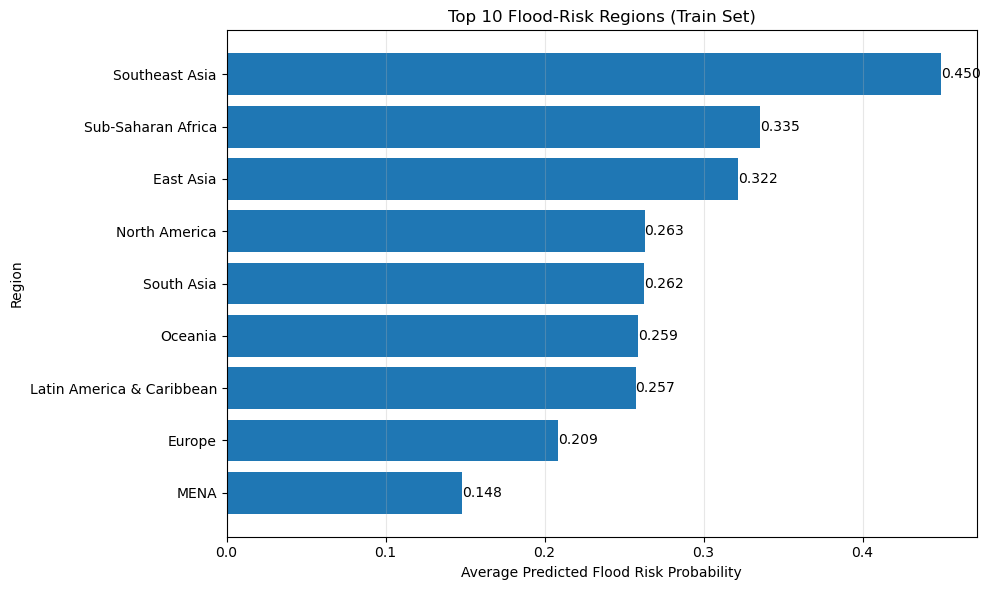

In [100]:
import matplotlib.pyplot as plt

# Convert the Series to a DataFrame for plotting
plot_df = top_areas_train.head(10).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.barh(
    plot_df[area_col],
    plot_df["flood_risk_proba"]
)

# Add values on the bars
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width():.3f}',
             va='center', ha='left', color='black')

plt.gca().invert_yaxis()  # highest risk at the top
plt.xlabel("Average Predicted Flood Risk Probability")
plt.ylabel("Region")
plt.title("Top 10 Flood-Risk Regions (Train Set)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

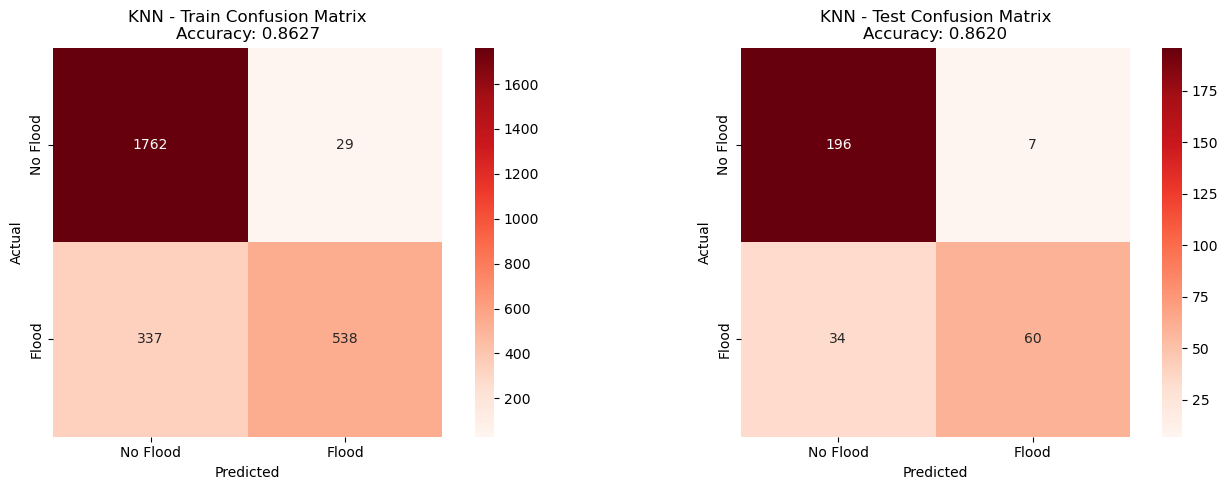

In [101]:
# Confusion Matrices
cm_train_dt = confusion_matrix(y_train, best_knn.predict(X_train))
cm_test_dt = confusion_matrix(y_test, best_knn.predict(X_test))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train confusion matrix
sns.heatmap(
    cm_train_dt,
    cmap="Reds",
    annot=True,
    fmt="g",
    square=True,
    xticklabels=["No Flood", "Flood"],
    yticklabels=["No Flood", "Flood"],
    ax=axes[0]
)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'KNN - Train Confusion Matrix\nAccuracy: {train_acc_dt:.4f}')

# Test confusion matrix
sns.heatmap(
    cm_test_dt,
    cmap="Reds",
    annot=True,
    fmt="g",
    square=True,
    xticklabels=["No Flood", "Flood"],
    yticklabels=["No Flood", "Flood"],
    ax=axes[1]
)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'KNN - Test Confusion Matrix\nAccuracy: {test_acc_dt:.4f}')

plt.tight_layout()
plt.show()

In [102]:
# Classification Report
print(f"\nKNN (k={gridsearch.best_params_['n_neighbors']}) - Test Set Classification Report:")
print(classification_report(y_test, best_knn.predict(X_test), target_names=["No Flood", "Flood"]))


KNN (k=17) - Test Set Classification Report:
              precision    recall  f1-score   support

    No Flood       0.85      0.97      0.91       203
       Flood       0.90      0.64      0.75        94

    accuracy                           0.86       297
   macro avg       0.87      0.80      0.83       297
weighted avg       0.87      0.86      0.85       297



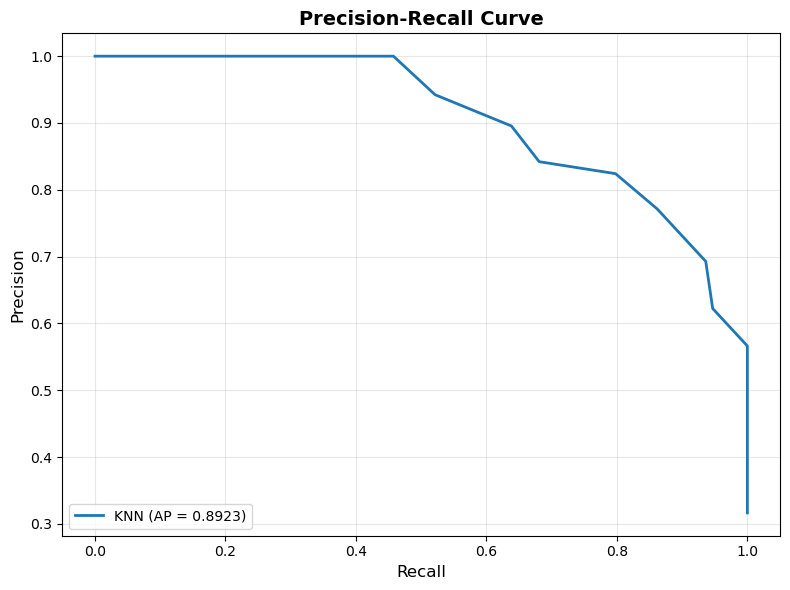

In [103]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Use probabilities, not class predictions
y_scores = best_knn.predict_proba(X_test)[:, 1]

precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_scores)

# Average precision (area under PR curve)
ap_knn = average_precision_score(y_test, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall_knn, precision_knn, label=f'KNN (AP = {ap_knn:.4f})', linewidth=2)

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

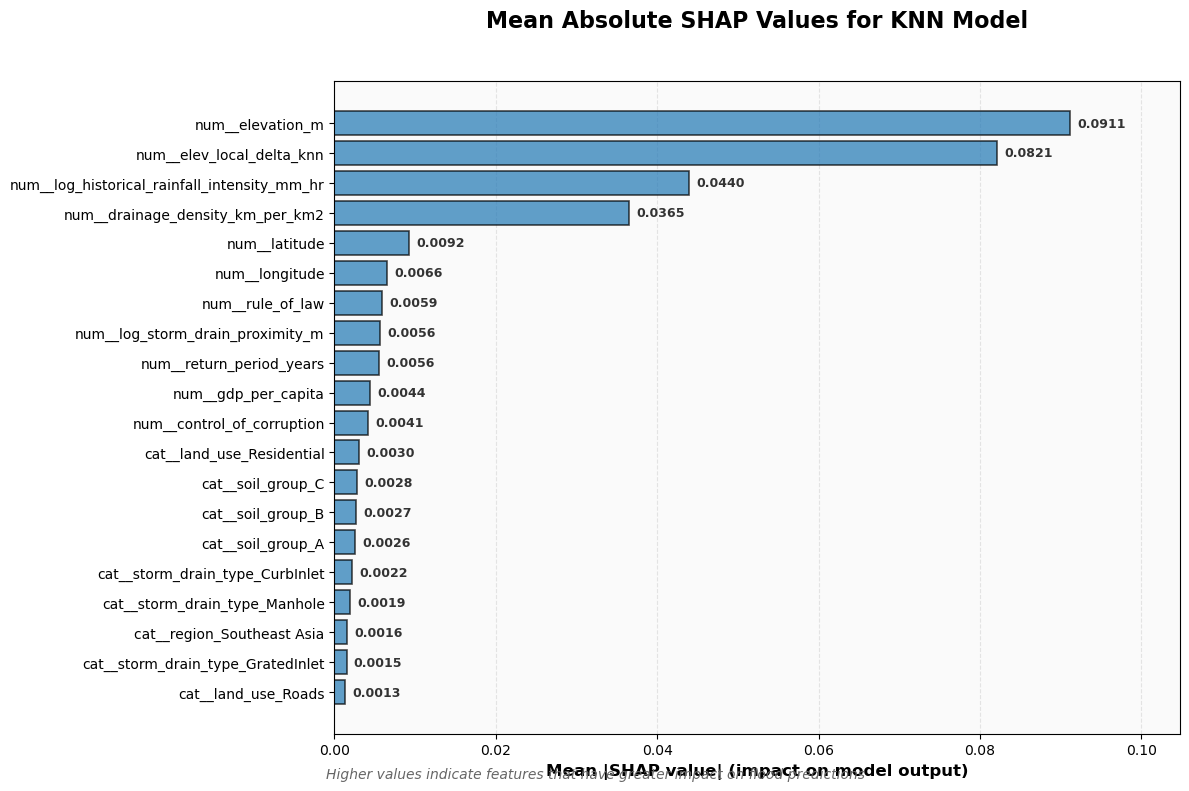

In [92]:
import shap
import numpy as np
import matplotlib.pyplot as plt # Import pyplot for title

from sklearn.neighbors import KNeighborsClassifier

# 1) Extract preprocessor and KNN from your pipeline
#    Adjust 'preprocess' / 'clf' if your step names differ
preproc = best_knn.named_steps['preprocess']
knn_orig = best_knn.named_steps['clf']

# 2) Transform X_train and X_test ONCE with the preprocessor
X_train_prep = preproc.transform(X_train)
X_test_prep  = preproc.transform(X_test)

# 3) Refit a plain KNN on the preprocessed data
knn_for_shap = KNeighborsClassifier(**knn_orig.get_params())
knn_for_shap.fit(X_train_prep, y_train)

# 4) Background sample for KernelExplainer
background = shap.sample(X_train_prep, 100, random_state=42)

# 5) Model function for SHAP (works purely on numpy arrays)
f = lambda x: knn_for_shap.predict_proba(x)[:, 1]

explainer = shap.KernelExplainer(f, background)

# 6) Take a subset of test points for explanation
X_sample = X_test_prep[:200]

shap_values = explainer.shap_values(X_sample)

# 7) Get feature names from the preprocessor (if available)
try:
    # Correctly access the ColumnTransformer within the pipeline
    feature_names = preproc.named_steps['encode_and_scale'].get_feature_names_out()
except Exception as e:
    print(f"Error getting feature names: {e}")
    feature_names = None  # SHAP will fall back to generic names

# 8) Calculate mean absolute SHAP values manually for custom plot
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create feature importance pairs
if feature_names is not None:
    feature_importance = list(zip(feature_names, mean_abs_shap))
else:
    feature_importance = list(zip([f"Feature {i}" for i in range(len(mean_abs_shap))], mean_abs_shap))

# Sort by importance
feature_importance.sort(key=lambda x: x[1], reverse=True)

# Take top 20 for better visibility
top_n = min(20, len(feature_importance))
top_features = feature_importance[:top_n]

# Extract names and values
names = [f[0] for f in top_features]
values = [f[1] for f in top_features]

# CREATE CUSTOM BAR CHART WITH VALUES BESIDE BARS
fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart
y_pos = np.arange(len(names))
bars = ax.barh(y_pos, values, color='#1f77b4', alpha=0.7, edgecolor='black', linewidth=1.2)

# ADD VALUE LABELS BESIDE EACH BAR
for i, (bar, value) in enumerate(zip(bars, values)):
    # Place text slightly to the right of the bar end
    ax.text(
        value + max(values) * 0.01,  # x position (1% to the right)
        i,                            # y position (centered on bar)
        f'{value:.4f}',              # formatted value with 4 decimals
        va='center',                 # vertical alignment
        ha='left',                   # horizontal alignment
        fontsize=9,
        fontweight='bold',
        color='#333333'
    )

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=10)
ax.set_xlabel('Mean |SHAP value| (impact on model output)', fontsize=12, fontweight='bold')
ax.set_title('Mean Absolute SHAP Values for KNN Model\n',
             fontsize=16, fontweight='bold', pad=20)

# Add grid for better readability
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Add subtle background color
ax.set_facecolor('#fafafa')

# Adjust x-axis limits to make room for labels
max_value = max(values)
ax.set_xlim([0, max_value * 1.15])  # Add 15% extra space

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Biggest at the top
plt.gca().invert_yaxis()  # highest risk at the top


# Add explanation text at the bottom
fig.text(0.5, 0.02,
         'Higher values indicate features that have greater impact on flood predictions',
         ha='center', fontsize=10, style='italic', color='#666666')

plt.show()

# Model 3: Decision Tree



**Decision Tree Without GridSearchCV**

In [104]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

decision_tree = Pipeline([
    ('preprocess', preproc),
    ('clf', DecisionTreeClassifier(
        max_depth=3,        # very simple tree
        random_state=42
    ))
])


In [105]:
decision_tree.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('add_region',
                                  RegionAdder(region_map={'Argentina': 'Latin '
                                                                       'America '
                                                                       '& '
                                                                       'Caribbean',
                                                          'Australia': 'Oceania',
                                                          'Bangladesh': 'South '
                                                                        'Asia',
                                                          'Brazil': 'Latin '
                                                                    'America & '
                                                                    'Caribbean',
                                                          'Cambodia': 'Southeast '
                                                                      'Asia',
                                                          'Canada': 'North '
                                                                    'America',
                                                          'Chile': 'Latin '
                                                                   'America & '
                                                                   'Caribbean',
                                                          'China': 'East Asia',
                                                          'Colombia': 'Latin '
                                                                      'Americ...
                                                                    'gdp_per_capita',
                                                                    'rule_of_law',
                                                                    'control_of_corruption',
                                                                    'population_density',
                                                                    'log_storm_drain_proximity_m',
                                                                    'log_historical_rainfall_intensity_mm_hr',
                                                                    'elev_local_delta_knn']),
                                                                  ('cat',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False),
                                                                   ['soil_group',
                                                                    'land_use',
                                                                    'storm_drain_type',
                                                                    'region'])]))])),
                ('clf', DecisionTreeClassifier(max_depth=3, random_state=42))])

In [106]:
# Get predictions
y_train_pred_dt = decision_tree.predict(X_train)
y_test_pred_dt = decision_tree.predict(X_test)

y_train_proba_dt = decision_tree.predict_proba(X_train)[:,1]
y_test_proba_dt = decision_tree.predict_proba(X_test)[:,1]

# Calculate metrics
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_test_pred_dt)

train_roc_dt = roc_auc_score(y_train, y_train_proba_dt)
test_roc_dt = roc_auc_score(y_test, y_test_proba_dt)

print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)
print(f"\nTrain Set:")
print(f"  Accuracy:  {train_acc_dt:.4f}")
print(f"  ROC-AUC:   {train_roc_dt:.4f}")

print(f"\nTest Set:")
print(f"  Accuracy:  {test_acc_dt:.4f}")
print(f"  ROC-AUC:   {test_roc_dt:.4f}")
print("=" * 60)

DECISION TREE PERFORMANCE

Train Set:
  Accuracy:  0.9966
  ROC-AUC:   0.9985

Test Set:
  Accuracy:  0.9933
  ROC-AUC:   0.9971


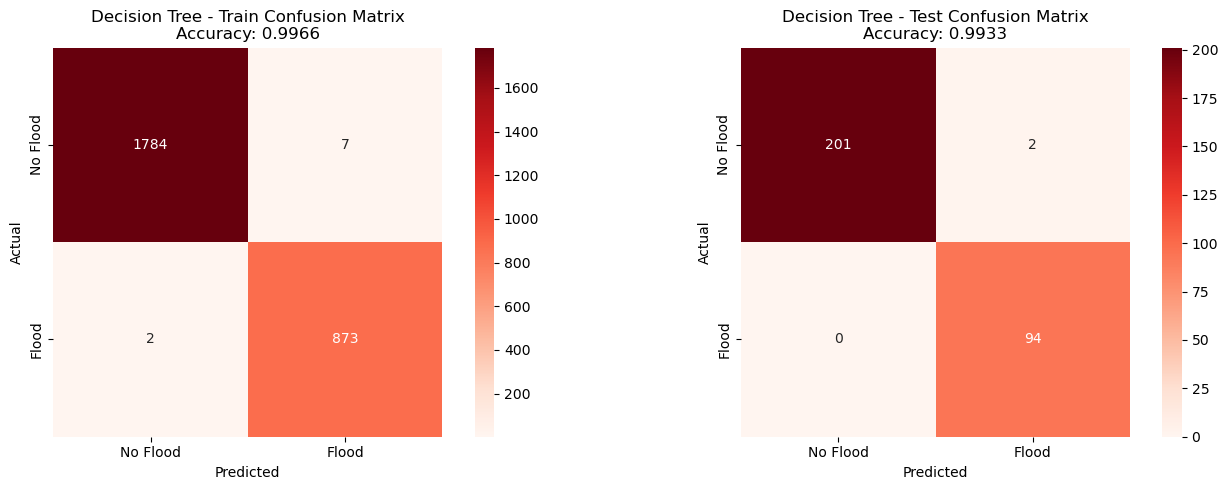

In [107]:
# Confusion Matrices
cm_train_dt = confusion_matrix(y_train, y_train_pred_dt)
cm_test_dt = confusion_matrix(y_test, y_test_pred_dt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train confusion matrix
sns.heatmap(
    cm_train_dt,
    cmap="Reds",
    annot=True,
    fmt="g",
    square=True,
    xticklabels=["No Flood", "Flood"],
    yticklabels=["No Flood", "Flood"],
    ax=axes[0]
)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Decision Tree - Train Confusion Matrix\nAccuracy: {train_acc_dt:.4f}')

# Test confusion matrix
sns.heatmap(
    cm_test_dt,
    cmap="Reds",
    annot=True,
    fmt="g",
    square=True,
    xticklabels=["No Flood", "Flood"],
    yticklabels=["No Flood", "Flood"],
    ax=axes[1]
)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Decision Tree - Test Confusion Matrix\nAccuracy: {test_acc_dt:.4f}')

plt.tight_layout()
plt.show()